In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
DOMINANCE_FACTOR = 2.0
MAX_DEPTH_m = 3000.0
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 0.0
ALIGNMENT_DEG = 45.0
RANDOM_TOLERANCE_FRACTION = ALIGNMENT_DEG / 180.0
SHELF_LON = 154.75

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

In [3]:
config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR,
    min_open_ocean_depth_m=MIN_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
df_eddies = add_pv_alignment_diagnostics(df_eddies, config)
d = df_eddies.copy()

In [4]:
planetary = d[d.open_ocean_planetary & d.direction_valid].copy()

In [5]:
topographic = d[d.shallow_ocean_topographic & d.direction_valid].copy()
topographic = topographic[np.isfinite(topographic.PV_grad_mag) & (topographic.PV_grad_mag > 0)]
topographic['log_PV_grad_mag'] = np.log(topographic.PV_grad_mag)
topographic['raw_signed_PV_mismatch'] = topographic.dtheta_PV_grad
topographic['preference_error'] = np.where(topographic.Cyc.eq('AE'),
    topographic.raw_signed_PV_mismatch, 180.0-topographic.raw_signed_PV_mismatch)
topographic['within_tolerance'] = topographic.preference_error <= ALIGNMENT_DEG
topographic['response_cosine'] = np.cos(np.deg2rad(topographic.raw_signed_PV_mismatch))
topographic['shelf_class'] = np.where(topographic.lon < SHELF_LON, 'On-shelf', 'Off-shelf')

In [25]:
np.linspace(0, 1, 9)

array([0.   , 0.125, 0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875, 1.   ])

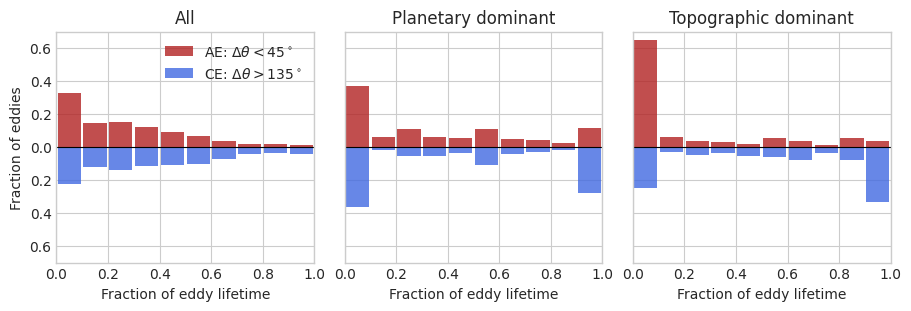

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True, constrained_layout=True)
bins = np.linspace(0, 1, 11)

for ax, df, title in zip(axs, [df_eddies, planetary, topographic],
                         ['All', 'Planetary dominant', 'Topographic dominant']):
    frac_ae = (df[df.Cyc.eq('AE')].groupby('Eddy').dtheta_PV_grad
               .apply(lambda x: (x.dropna() < 45).mean()).dropna())
    frac_ce = (df[df.Cyc.eq('CE')].groupby('Eddy').dtheta_PV_grad
               .apply(lambda x: (x.dropna() > 135).mean()).dropna())

    ha, _ = np.histogram(frac_ae, bins)
    hc, _ = np.histogram(frac_ce, bins)
    x = (bins[:-1] + bins[1:]) / 2

    ax.bar(x,  ha/ha.sum(), .09, color='firebrick', alpha=.8,
           label=r'AE: $\Delta\theta<45^\circ$')
    ax.bar(x, -hc/hc.sum(), .09, color='royalblue', alpha=.8,
           label=r'CE: $\Delta\theta>135^\circ$')
    ax.axhline(0, color='k', lw=.8)
    ax.set(xlim=(0, 1), title=title, xlabel='Fraction of eddy lifetime')
    ax.yaxis.set_major_formatter(lambda x, _: f'{abs(x):.1f}')
yabs = max(np.abs(axs[0].get_ylim()))
axs[0].set_ylim(-yabs,yabs)
    
axs[0].set_ylabel('Fraction of eddies')
axs[0].legend(frameon=False)

<Axes: >

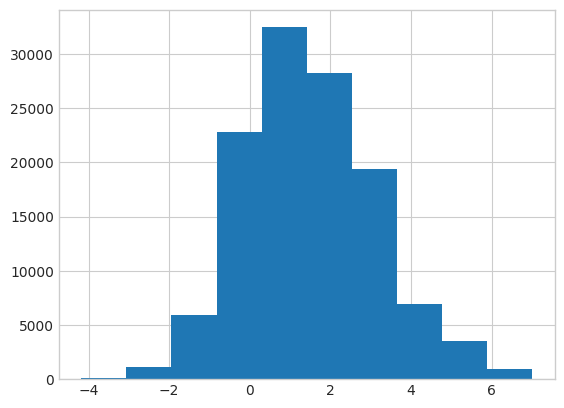

In [6]:
df_eddies.topo_plan_ratio_smooth.hist()

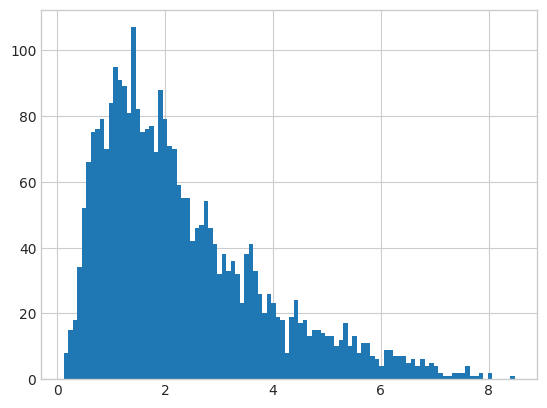

In [7]:
topo_plan_ratio_ranges = df_eddies.groupby('Eddy').topo_plan_ratio_smooth.agg(lambda x: x.max() - x.min())
_ = plt.hist(topo_plan_ratio_ranges, bins=100)


In [12]:
s = df_eddies.groupby('Eddy').topo_plan_ratio_smooth.agg(['min','max'])
trans_eddies = s.index[(s['max'] > 2) & (s['min'] < -2)]

df = df_eddies[df_eddies.Eddy.isin(trans_eddies)].sort_values(['Eddy','Age']).copy()
df['sign'] = np.sign(df.topo_plan_ratio_smooth)

ntrans = df.groupby('Eddy').sign.apply(lambda x: x.ne(x.shift()).sum() - 1)
trans_eddies = ntrans[ntrans<4].index

df_trans = df[df.Eddy.isin(trans_eddies) & df.Age.gt(20)].copy()

df_trans.groupby('Cyc').Eddy.nunique()


Cyc
AE    5
CE    2
Name: Eddy, dtype: int64

In [9]:
def time_plot(eddy, df_data, grid=grid):
    df = df_data[df_data.Eddy.eq(eddy)].copy()
    t = df.Day - df.Day.iloc[0]

    fig = plt.figure(figsize=(12,10))
    gs = fig.add_gridspec(6, 2, width_ratios=[2,1])
    axs = [fig.add_subplot(gs[i,0]) for i in range(6)]
    south = df.TiltDir.between(90, 270)
    for ax in axs:
        for i in np.where(south)[0]:
            ax.axvspan(t.iloc[i]-.5, t.iloc[i]+.5, color='grey', alpha=.12, lw=0)
    axm = fig.add_subplot(gs[:,1])

    axs[0].plot(t, df.TiltDis)
    axs[0].set_ylabel('TiltDis')
    ax0 = axs[0].twinx()
    ax0.plot(t, df.PV_grad_mag, color='tab:red')
    ax0.set_ylabel('PV grad mag', color='tab:red')

    axs[1].plot(t, np.exp(df.topo_plan_ratio))
    axs[1].plot(t, np.exp(df.topo_plan_ratio_smooth))
    axs[1].set_ylabel('Topo/plan')

    axs[2].plot(t, df.Ro)
    axs[2].set_ylabel('Ro')
    ax2 = axs[2].twinx()
    ax2.plot(t, df.w, color='tab:red', label='w')
    # ax2.plot(t, df.f, color='tab:orange', label='f')
    ax2.set_ylabel('w')

    axs[3].plot(t, df.PV)
    axs[3].set_ylabel('PV')
    ax3 = axs[3].twinx()
    ax3.plot(t, df.h, color='tab:red')
    ax3.invert_yaxis()
    ax3.set_ylabel('h', color='tab:red')

    axs[4].plot(t, df.beta)
    axs[4].set_ylabel('beta')
    ax4 = axs[4].twinx()
    ax4.plot(t, df.w+df.f, color='tab:red')
    ax4.set_ylabel('abs_vort = w + f', #'Latitude', 
                   color='tab:red')

    axs[5].scatter(t, df.PV_grad_theta, s=10, label='PV grad')
    axs[5].scatter(t, df.TiltDir, s=10, label='Tilt')
    axs[5].plot(t, df.TiltDir)
    axs[5].scatter(t, df.dtheta_PV_grad, s=10, label=r'$\Delta\theta$')
    axs[5].axhspan(90, 270, color='grey', alpha=.15)
    axs[5].set(xlabel='Eddy age [days]', ylabel='Direction [°]')
    axs[5].legend()

    th = np.deg2rad(df.TiltDir)
    xb = df.xc - df.TiltDis*np.sin(th)
    yb = df.yc - df.TiltDis*np.cos(th)
    
    pad = 20
    xmin, xmax = min(df.xc.min(), xb.min())-pad, max(df.xc.max(), xb.max())+pad
    ymin, ymax = min(df.yc.min(), yb.min())-pad, max(df.yc.max(), yb.max())+pad
    
    ii = ((grid.X_grid >= xmin) & (grid.X_grid <= xmax) &
          (grid.Y_grid >= ymin) & (grid.Y_grid <= ymax))

    h = np.where((grid.mask_rho == 1) & ii, grid.h/1e3, np.nan)
    cf = axm.contourf(grid.X_grid, grid.Y_grid, h, cmap='Greys_r')
    fig.colorbar(cf, ax=axm, label='Depth (km)', shrink=.5)
    
    axm.set(xlim=(xmin,xmax), ylim=(ymin,ymax))

    cyc = df.iloc[0].Cyc
    clr = 'r' if cyc == 'AE' else 'b'
    axm.plot(df.xc, df.yc, '.-', color=clr, label='Surface')
    axm.scatter(xb, yb, s=10, color=clr, label='Bottom')
    for xs, ys, xbot, ybot, theta in zip(df.xc, df.yc, xb, yb, df.dtheta_PV_grad):
        clr = 'g' if theta<(180-45) else 'r'
        axm.plot([xs, xbot], [ys, ybot], color=clr, alpha=.25)

    axm.set(xlabel='x (km)', ylabel='y (km)')
    axm.set_aspect('equal')
    axm.legend()

    fig.suptitle(f'{cyc}{eddy}')
    plt.tight_layout()
    plt.show()

(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

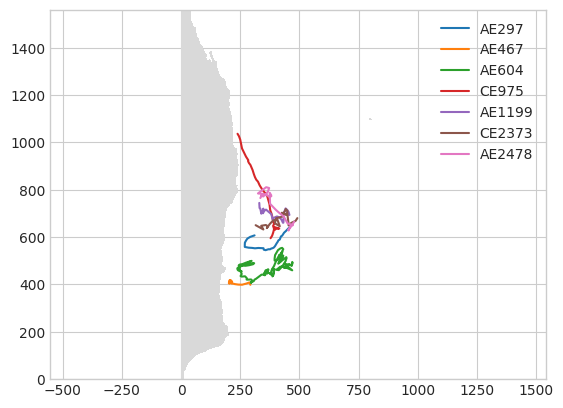

In [13]:
plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, np.nan,0))
for eddy in df_trans.Eddy.unique():
    df = df_trans[df_trans.Eddy==eddy].copy()
    plt.plot(df.xc, df.yc, label=f'{df.iloc[0].Cyc}{eddy}')
plt.legend()
plt.axis('equal')

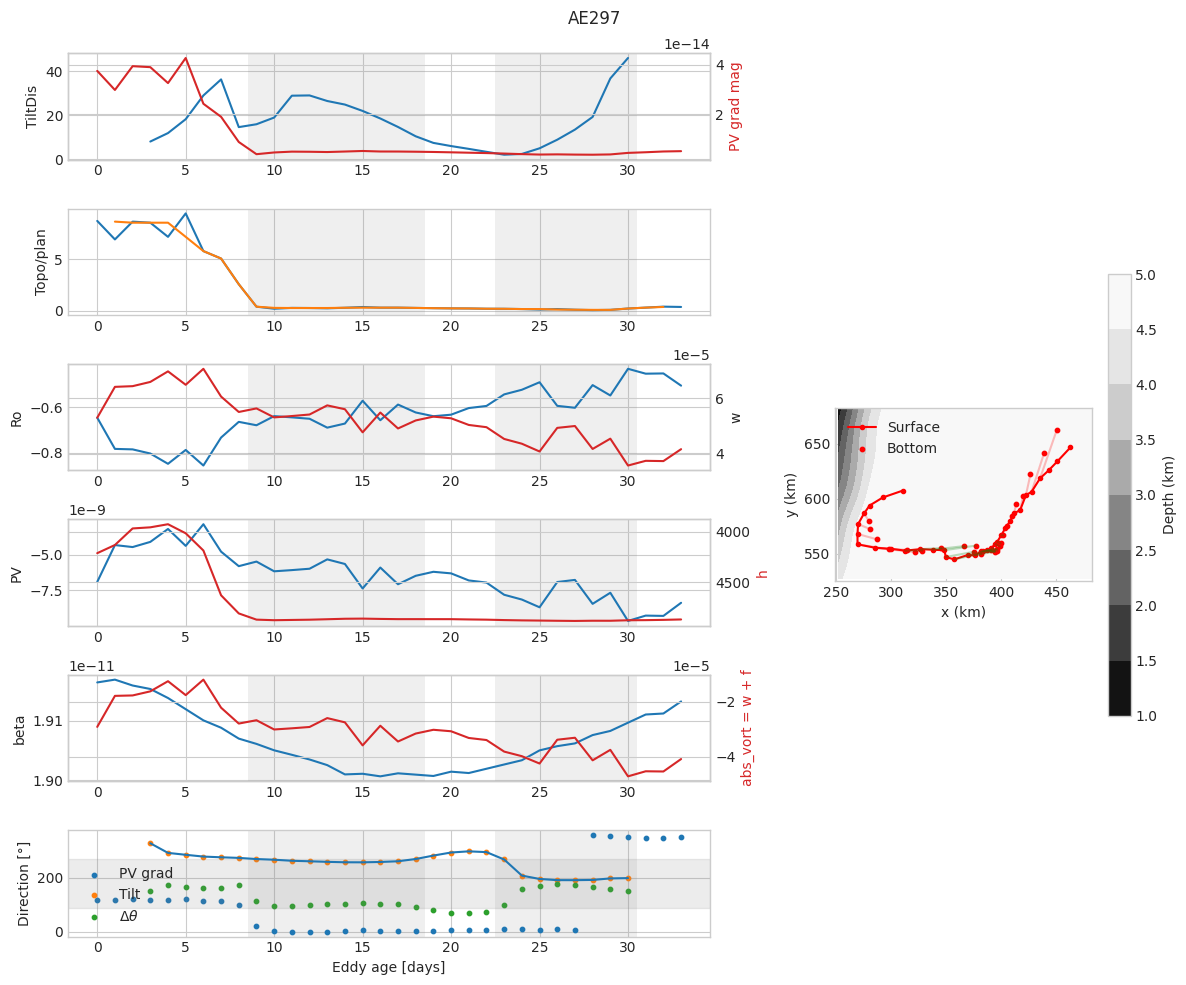

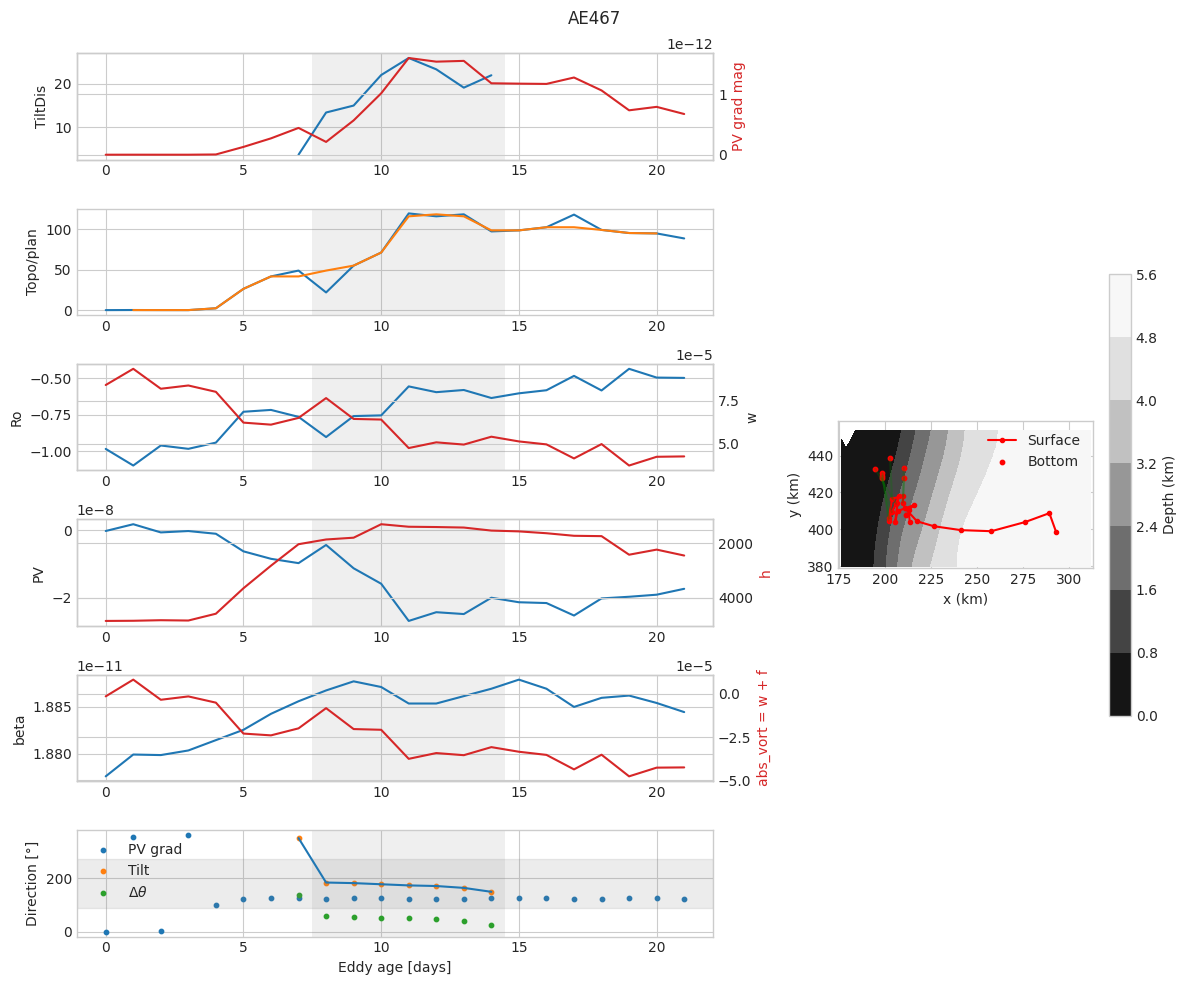

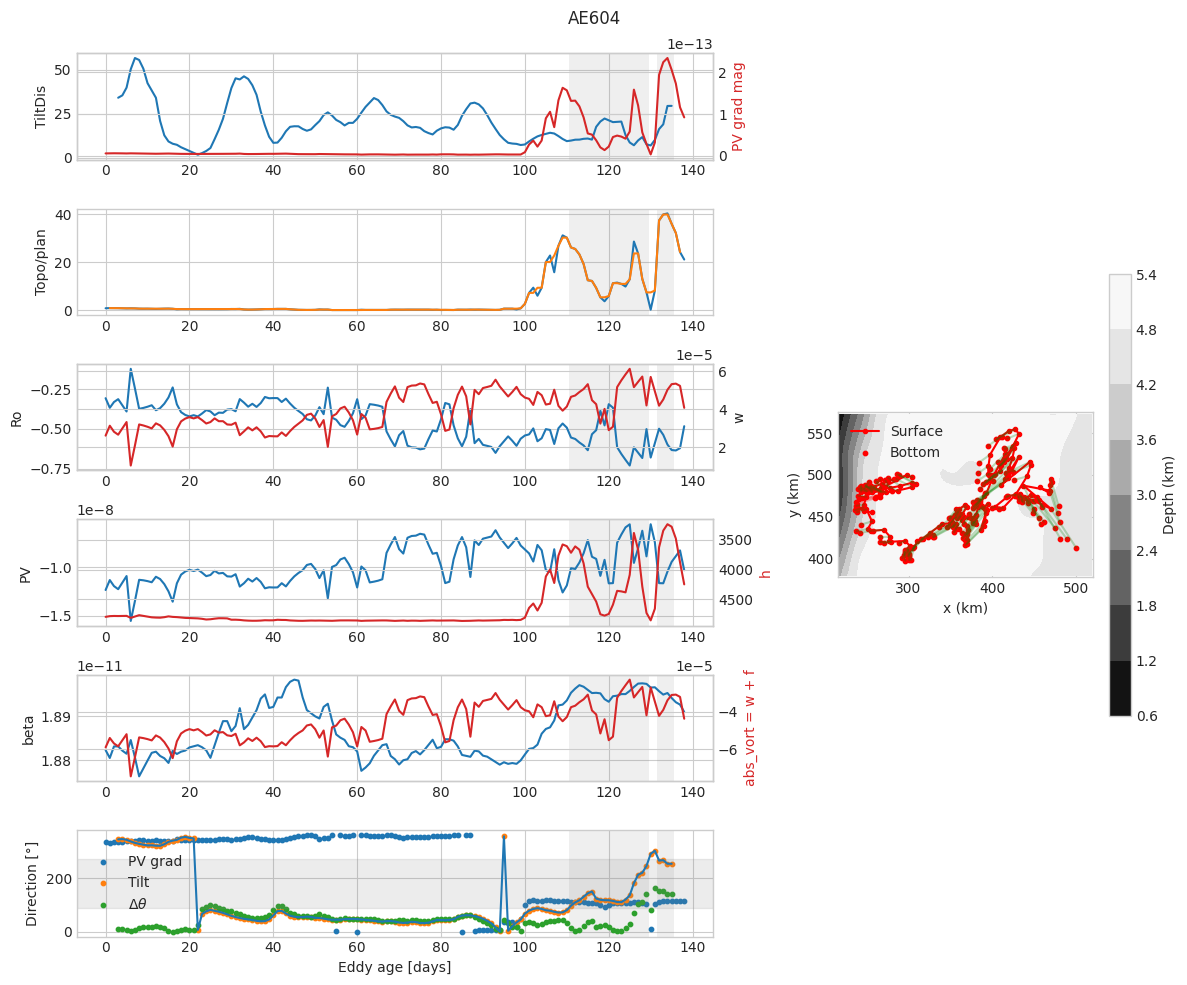

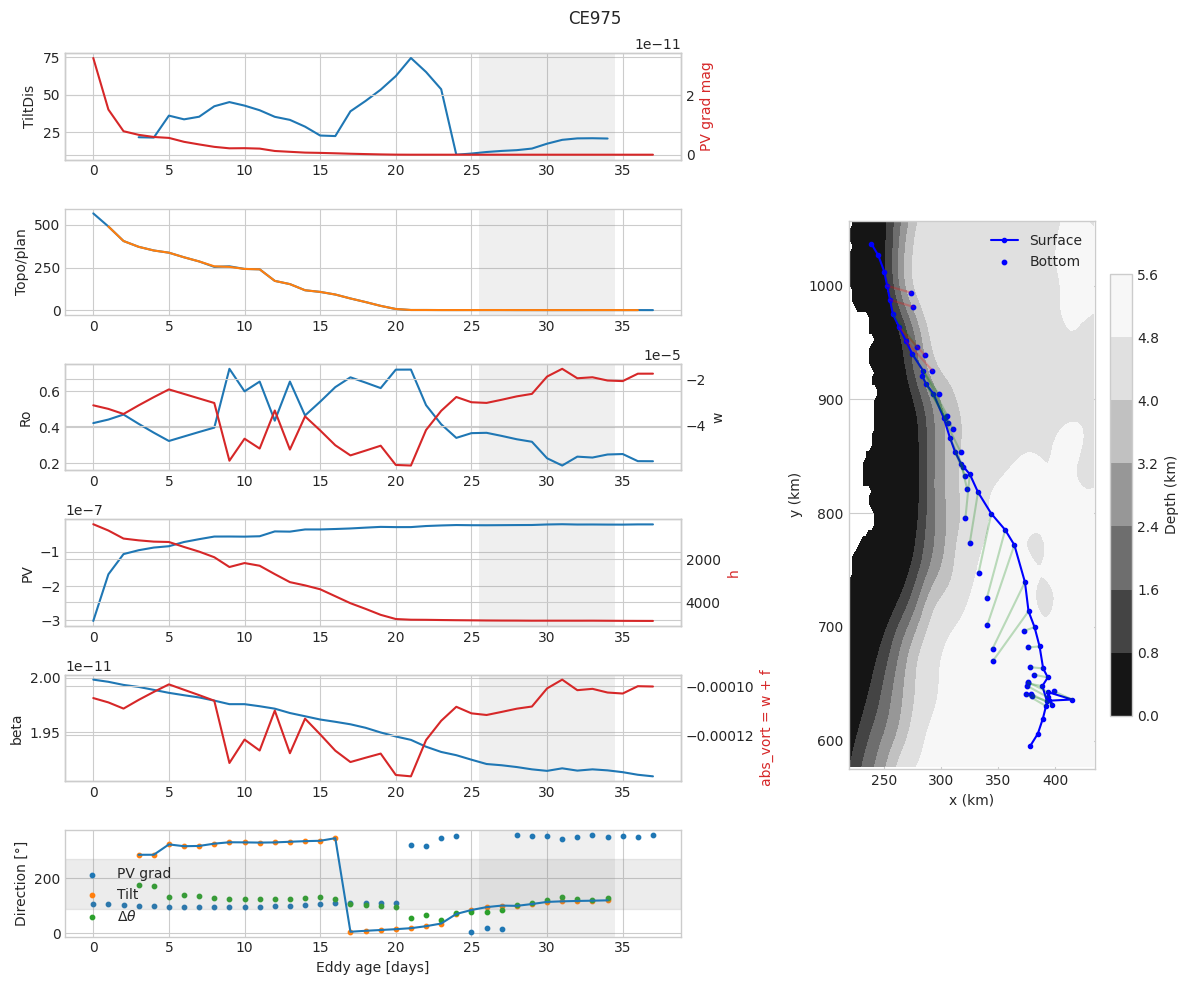

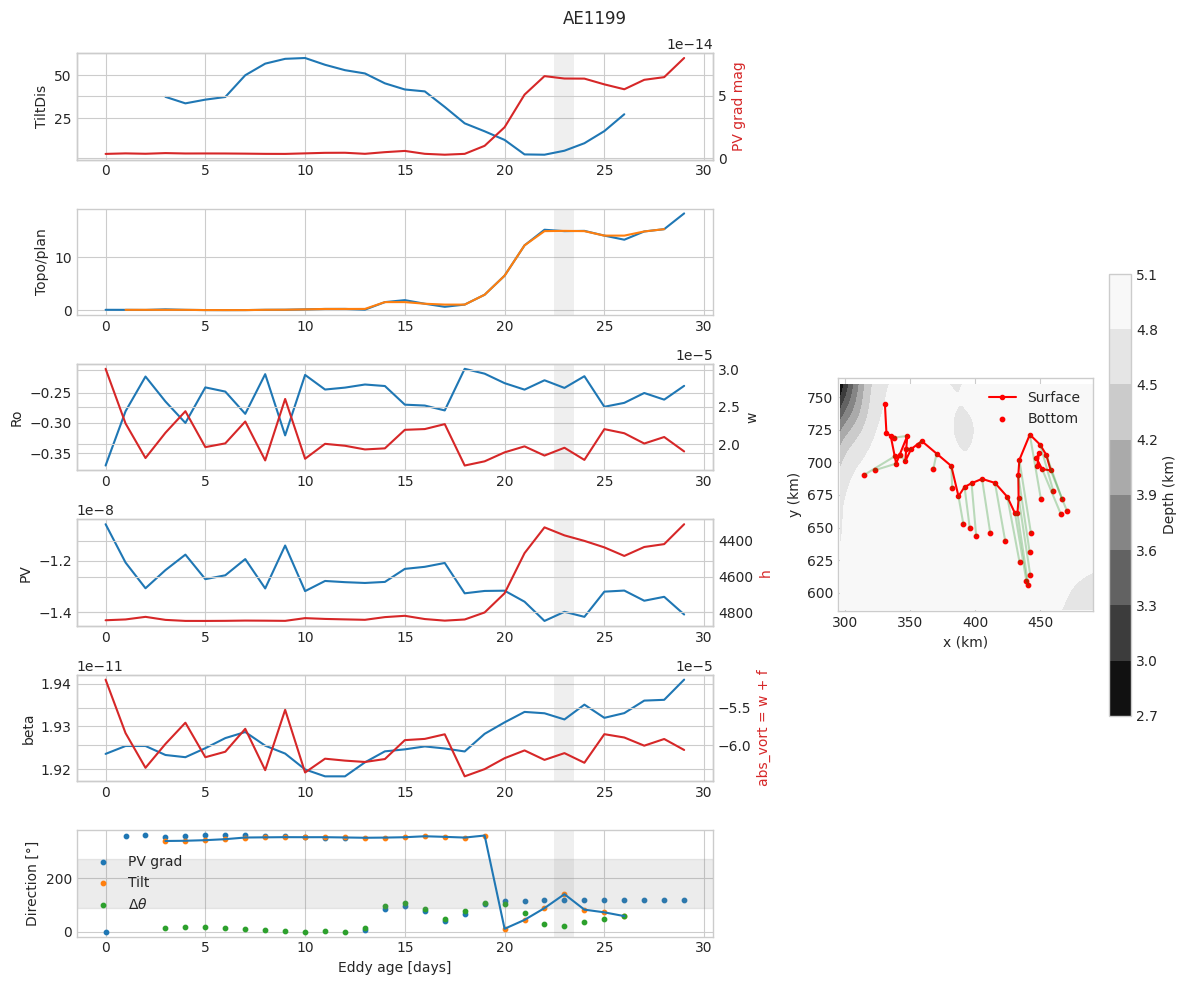

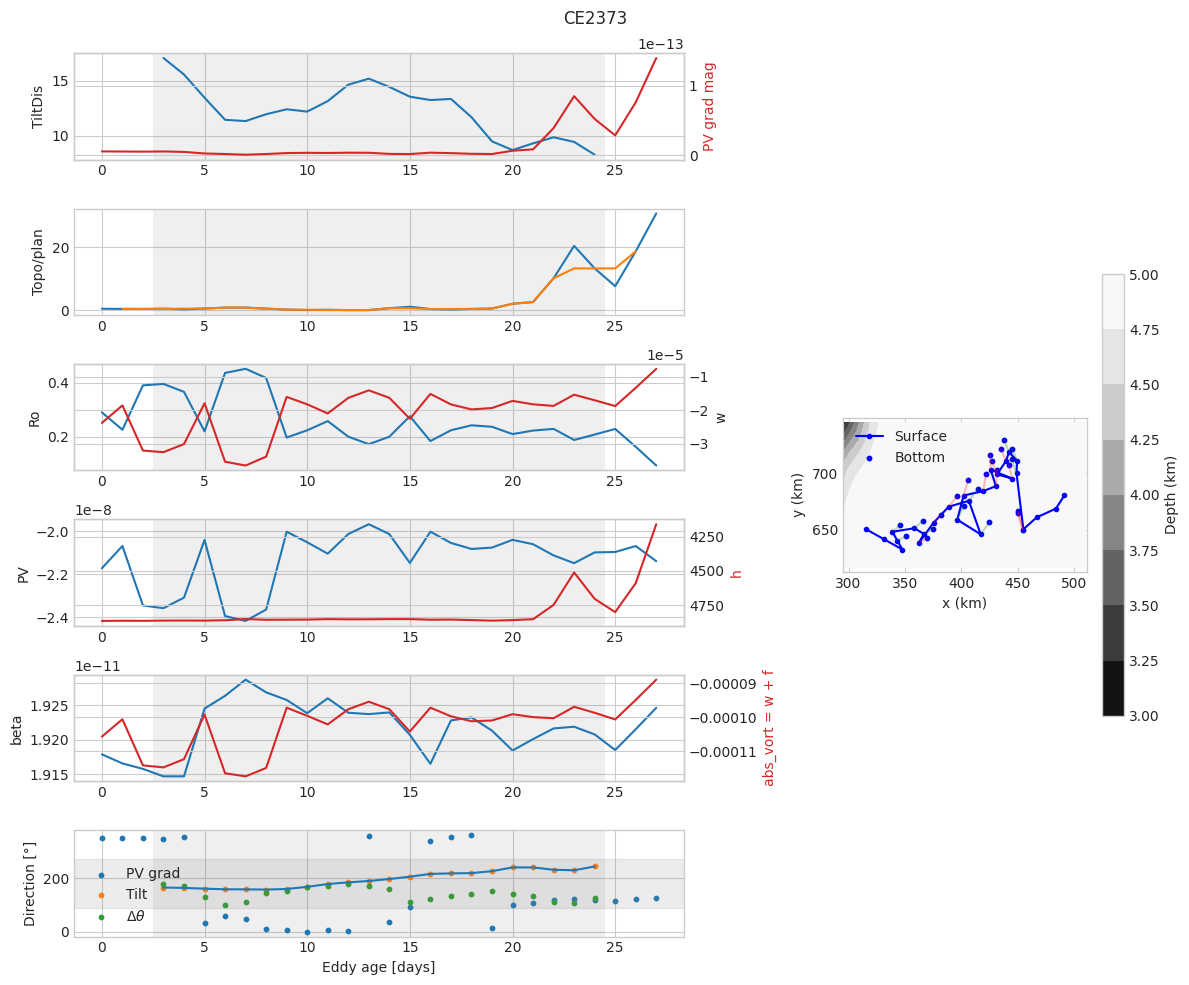

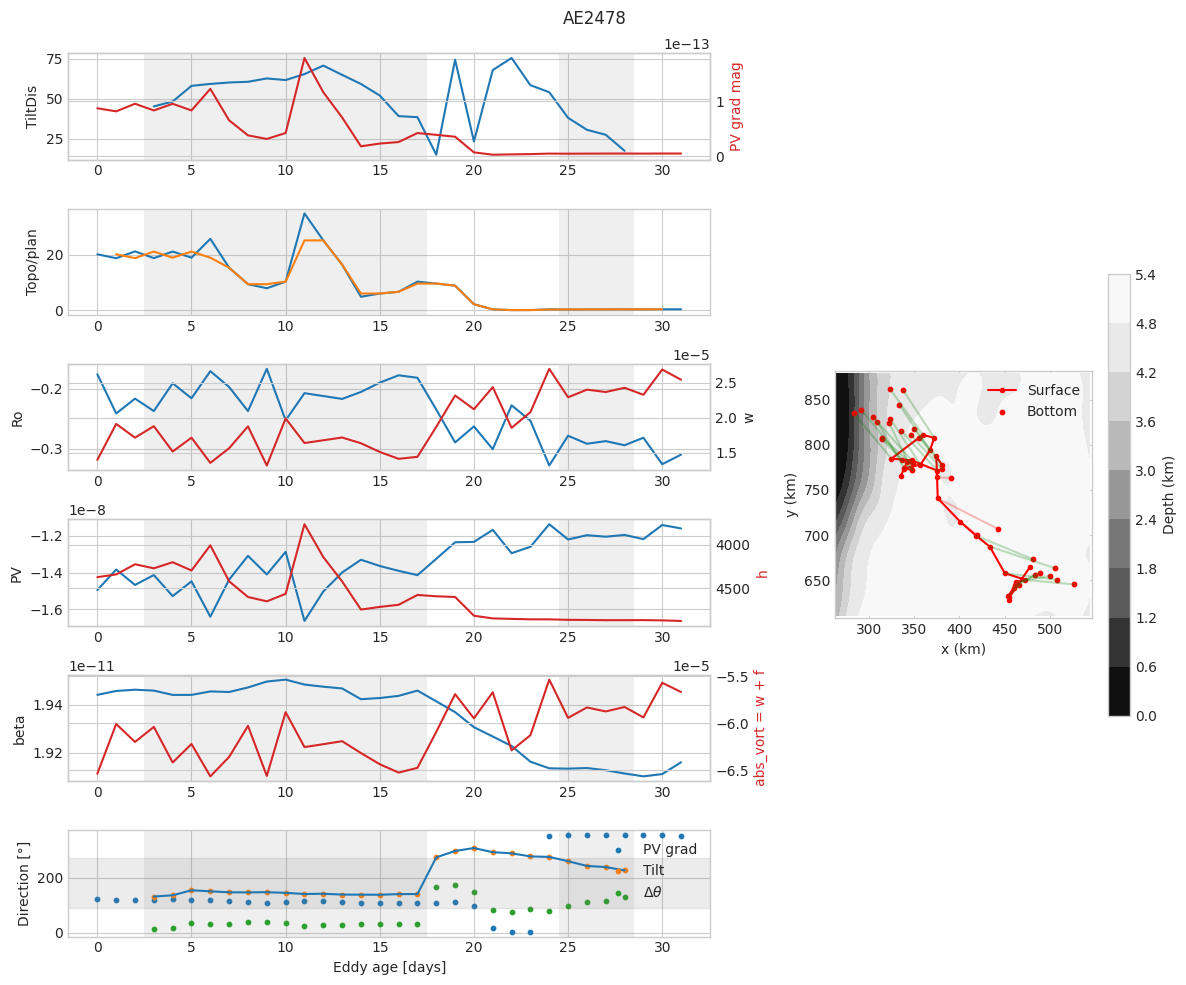

In [14]:
for eddy in df_trans.Eddy.unique():
    time_plot(eddy, df_trans, grid)